# Embeddings and Retrieval
## CAS NLP 2025/2026,  University of Bern — Final Project

Multilingual embedding generation and vector index construction.
Embedding model: `paraphrase-multilingual-MiniLM-L12-v2` (local CPU).
To switch to GPUStack: replace model name and add base_url + api_key.
Vector store: ChromaDB (persistent, local).

## 1. Environment Setup

In [4]:
import json
import pathlib
import os
import pandas as pd

os.chdir('/Users/Olga 1/Documents/01_AD_ASTRA/0102_LANGUAGES/CAS_NLP_2025/final_project')

# Load chunks from NB02 output
with open("data/chunks/chunks.json", encoding="utf-8") as f:
    records = json.load(f)

df = pd.DataFrame(records)
print(f"Chunks loaded: {len(df)}")
print(df["chunk_type"].value_counts())

Chunks loaded: 375
chunk_type
chapter        312
full            36
preamble        15
age_section     12
Name: count, dtype: int64


## 2. Embedding Model

Local development model: `paraphrase-multilingual-MiniLM-L12-v2`
Supports 50+ languages including all corpus languages (DE/FR/IT/RU/SQ/TI/ES).
Runs on CPU — no GPU required for local testing.

To switch to production model (UniBE GPUStack):
replace model name and add base_url + api_key in the SentenceTransformer call.

In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

print(f"Model loaded: {model.get_sentence_embedding_dimension()} dimensions")

Model loaded: 384 dimensions


## 3. Generate Embeddings

Embed all 375 chunks using the multilingual model.
Texts are extracted from the `text` field of each chunk.
This may take a few minutes on CPU.

In [3]:
texts = df["text"].tolist()
embeddings = model.encode(texts, show_progress_bar=True, batch_size=32)

print(f"Embeddings shape: {embeddings.shape}")

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Embeddings shape: (375, 384)


## 4. Vector Index — ChromaDB

ChromaDB stores chunk embeddings as vectors on disk and writes automatically 
at each operation — no explicit save step required.
The collection `jugend_medien` is stored in `data/chroma/` and reloadable 
in any subsequent notebook via `chromadb.PersistentClient(path="data/chroma")`.

At query time, the user question is embedded with the same model and compared 
against all chunk vectors using cosine similarity. The most similar chunks 
are returned as retrieval candidates for the LLM.

In [5]:
import chromadb

# Persistent client — embeddings saved to disk
chroma_client = chromadb.PersistentClient(path="data/chroma")

# Create or load collection
collection = chroma_client.get_or_create_collection(
    name="jugend_medien",
    metadata={"hnsw:space": "cosine"}
)

# Prepare data for indexing
ids        = [f"chunk_{i}" for i in range(len(df))]
documents  = df["text"].tolist()
metadatas  = df[["source", "lang", "chunk_type", "title"]].to_dict(orient="records")

# Add to collection in batches
collection.add(
    ids=ids,
    embeddings=embeddings.tolist(),
    documents=documents,
    metadatas=metadatas
)

print(f"Indexed: {collection.count()} chunks")

Indexed: 375 chunks


## 5. Retrieval Test

Given a query in any language, the retrieval pipeline:
1. Encodes the query into a 384-dimensional vector using the same model
2. Compares this vector against all 375 chunk vectors using cosine similarity
3. Returns the n most similar chunks (n_results)

The query and the chunks can be in different languages — the multilingual
model maps semantically similar content to nearby vectors regardless of language.
This is the core of cross-lingual retrieval: a question in Albanian can retrieve
a relevant chunk in German or French.

Metadata filters can narrow the search (e.g. by language or chunk type)
but are not applied here — we test open retrieval across the full corpus.

## 5.1 Baseline Retrieval — French Query

Single query test in French to validate retrieval pipeline.

In [6]:
def retrieve(query, n_results=3):
    # Encode the query using the same model as the chunks
    query_embedding = model.encode([query])[0]

    # Query ChromaDB for the most similar chunks
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=n_results,
        include=["documents", "metadatas", "distances"]
    )

    # Display results
    print(f"Query: {query}\n")
    for i, (doc, meta, dist) in enumerate(zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    )):
        print(f"--- Result {i+1} ---")
        print(f"Source : {meta['source']} | Lang: {meta['lang']} | Type: {meta['chunk_type']}")
        print(f"Title  : {meta['title']}")
        print(f"Score  : {1 - dist:.3f} (cosine similarity)")
        print(f"Text   : {doc[:200]}...")
        print()

# Test with Q01 from test_queries.json — screen time, child 3 years old
retrieve("Mon enfant a 3 ans. Combien de temps par jour pour la télé ou la tablette ?")

Query: Mon enfant a 3 ans. Combien de temps par jour pour la télé ou la tablette ?

--- Result 1 ---
Source : jm-b-2024-recommendations_de.txt | Lang: de | Type: chapter
Title  : 03_MEDIENREGELN
Score  : 0.653 (cosine similarity)
Text   : 03_MEDIENREGELN
 
11
Wie viel Bildschirmzeit in welchem Alter – 
woran kann man sich orientieren?
Oft wird der Wunsch nach verbindlichen Richtwerten zur 
Orientierung laut. Reine Zeitangaben sind meis...

--- Result 2 ---
Source : jm-f-ext_sq.txt | Lang: sq | Type: age_section
Title  : Shpjegime lidhur me rekomandim
Score  : 0.585 (cosine similarity)
Text   : Shpjegime lidhur me rekomandimet për përdorimin e mediave dixhitale –  
Për prindërit e fëmijëve midis 6 dhe 13 vjeç 
 
 
 
Kushtojini vëmendje në mënyrë të ekuilibruar organizimit të kohës së lirë. 
...

--- Result 3 ---
Source : jm-b-2021-school_fr.txt | Lang: fr | Type: chapter
Title  : 01_L’UTILISATION DES OUTILS  
Score  : 0.569 (cosine similarity)
Text   : 01_L’UTILISATION DES OUTILS  
ET M

## 5.2 Cross-Lingual Retrieval — Minority Languages

Retrieval scores for Russian, Albanian,  Tigrinya and Spanish queries.
These scores complete the evaluation table in Section 5 of the report.

In [ ]:
# Query RU /SQ/TI/ES— Q01/Q08
test_queries = [
    ("Q01/RU", "Моему ребёнку 3 года. Сколько можно смотреть телевизор или планшет в день?"),
    ("Q01/SQ", "Fëmija im është 3 vjeç. Sa kohë në ditë mund të shikojë televizor ose tablet?"),
    ("Q01/TI", "ቆልዓይ 3 ዓመት እዩ። ኣብ መዓልቲ ክንደይ ሰዓት ተለቪዥን ወይ ታብለት ክርኢ ይኽእል?"),
    ("Q08/ES", "Publico fotos de mi hijo en WhatsApp e Instagram. ¿Es un problema?"),
]

for label, query in test_queries:
    embedding = model.encode([query])[0].tolist()
    results = collection.query(query_embeddings=[embedding], n_results=3,
                               include=["documents", "metadatas", "distances"])
    print(f"\n=== {label} ===")
    for i, (doc, meta, dist) in enumerate(zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    )):
        score = 1 - dist
        print(f"[{i+1}] {meta['source']} | score: {score:.3f}")


=== Q01/RU ===
[1] jm-b-2021-school_it.txt | score: 0.627
[2] jm-b-2021-school_fr.txt | score: 0.609
[3] jm-b-2024-recommendations_de.txt | score: 0.592

=== Q01/SQ ===
[1] jm-b-2024-recommendations_de.txt | score: 0.643
[2] jm-f-ext_sq.txt | score: 0.565
[3] jm-b-2021-school_it.txt | score: 0.553

=== Q01/TI ===
[1] jm-f-ext_ti.txt | score: 0.792
[2] jm-f-ext_ti.txt | score: 0.790
[3] jm-f-2020-6-13_ti.txt | score: 0.718

=== Q08/ES ===
[1] jm-f-2021-image-rights-parents_fr.txt | score: 0.521
[2] jm-f-2021-image-rights-youth_de.txt | score: 0.512
[3] jm-f-2021-image-rights-youth_it.txt | score: 0.508


## 5.3 Retrieval Score Distribution

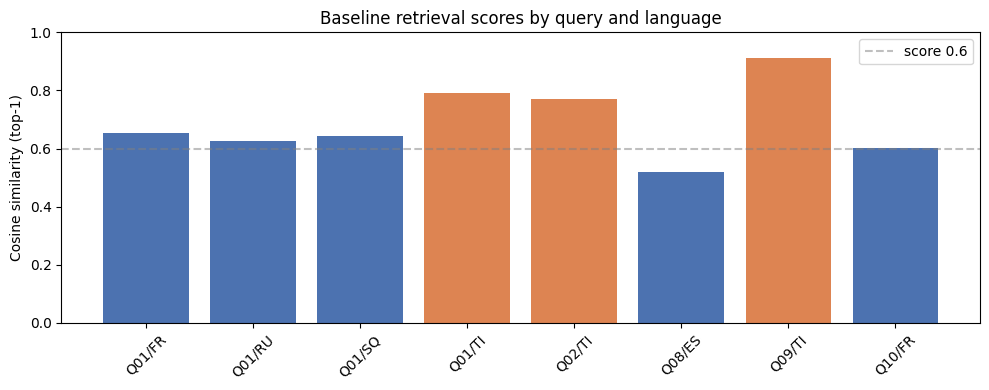

Figure saved.


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# scores from cross-lingual test (5.2)
labels = ["Q01/FR", "Q01/RU", "Q01/SQ", "Q01/TI", "Q02/TI", "Q08/ES", "Q09/TI", "Q10/FR"]
scores = [0.653, 0.627, 0.643, 0.792, 0.771, 0.521, 0.910, 0.603]
colors = ["#4C72B0" if not l.endswith("TI") else "#DD8452" for l in labels]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, scores, color=colors)
ax.axhline(y=0.6, color="gray", linestyle="--", alpha=0.5, label="score 0.6")
ax.set_ylim(0, 1)
ax.set_ylabel("Cosine similarity (top-1)")
ax.set_title("Baseline retrieval scores by query and language")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig("report/figures/nb03_retrieval_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 6. Baseline Retrieval — Full Test Suite

All 10 evaluation queries tested across 8 languages.
Key scores documented in report Section 5.1.
Re-run this cell to reproduce baseline results.

In [13]:
import json

with open("data/eval/test_queries.json", encoding="utf-8") as f:
    test_queries = json.load(f)

# Test toutes les queries dans toutes les langues
for q in test_queries["queries"]:
    print(f"\n{'='*60}")
    print(f"Q{q['id']} — {q['theme']}")
    for lang, query_text in q["translations"].items():
        print(f"\n  [{lang}]")
        retrieve(query_text, n_results=2)


QQ01 — screen_time_0-7

  [EN]
Query: My child is 3 years old. How much TV or tablet per day is okay?

--- Result 1 ---
Source : jm-b-2024-recommendations_de.txt | Lang: de | Type: chapter
Title  : 03_MEDIENREGELN
Score  : 0.548 (cosine similarity)
Text   : 03_MEDIENREGELN
 
11
Wie viel Bildschirmzeit in welchem Alter – 
woran kann man sich orientieren?
Oft wird der Wunsch nach verbindlichen Richtwerten zur 
Orientierung laut. Reine Zeitangaben sind meis...

--- Result 2 ---
Source : jm-f-ext_sq.txt | Lang: sq | Type: age_section
Title  : Shpjegime lidhur me rekomandim
Score  : 0.533 (cosine similarity)
Text   : Shpjegime lidhur me rekomandimet për përdorimin e mediave dixhitale –  
Për prindërit e fëmijëve midis 6 dhe 13 vjeç 
 
 
 
Kushtojini vëmendje në mënyrë të ekuilibruar organizimit të kohës së lirë. 
...


  [FR]
Query: Mon enfant a 3 ans. Combien de temps par jour pour la télé ou la tablette ?

--- Result 1 ---
Source : jm-b-2024-recommendations_de.txt | Lang: de | Type: chap